In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

In [14]:
import os
print(os.getcwd())
print(os.listdir(".."))


C:\Users\91924\OneDrive\Documents\rainfall\notebooks
['.idea', '.venv', 'config', 'ingestion', 'notebooks']


In [17]:
DATA_PATH = "../ingestion/data/raw/district_weather_daily.csv"
df = pd.read_csv(DATA_PATH)

df["date"] = pd.to_datetime(df["date"])
df.head()

,date,district,rainfall_mm,temperature_2m_mean,relative_humidity_2m_mean,surface_pressure_mean,wind_speed_10m_mean,cloud_cover_mean
0,2015-01-01,Chengalpattu,0.0,24.9,87,1003.3,5.6,38
1,2015-01-02,Chengalpattu,1.3,25.2,88,1005.7,8.0,38
2,2015-01-03,Chengalpattu,1.2,25.2,89,1006.9,6.4,52
3,2015-01-04,Chengalpattu,0.4,25.1,88,1006.9,5.3,35
4,2015-01-05,Chengalpattu,0.2,24.8,83,1006.6,7.9,20


In [19]:
print("Total rows:", len(df))
print("Date range:", df["date"].min(), "→", df["date"].max())
print("Districts:", df["district"].unique())


Total rows: 21918
Date range: 2015-01-01 00:00:00 → 2024-12-31 00:00:00
Districts: ['Chengalpattu' 'Chennai' 'Cuddalore' 'Kancheepuram' 'Nagapattinam'
 'Tiruvallur']


In [20]:
df.groupby("district").size()

district
Chengalpattu    3653
Chennai         3653
Cuddalore       3653
Kancheepuram    3653
Nagapattinam    3653
Tiruvallur      3653
dtype: int64

In [21]:
def missing_dates(group):
    full_range = pd.date_range(
        start=group["date"].min(),
        end=group["date"].max(),
        freq="D"
    )
    return len(full_range) - group["date"].nunique()

missing = (
    df.groupby("district")
      .apply(missing_dates)
)

missing

C:\Users\91924\AppData\Local\Temp\ipykernel_19940\3517077127.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(missing_dates)


district
Chengalpattu    0
Chennai         0
Cuddalore       0
Kancheepuram    0
Nagapattinam    0
Tiruvallur      0
dtype: int64

In [22]:
df["rainfall_mm"].describe()

count    21918.000000
mean         3.596272
std          9.846442
min          0.000000
25%          0.000000
50%          0.400000
75%          2.800000
max        255.800000
Name: rainfall_mm, dtype: float64

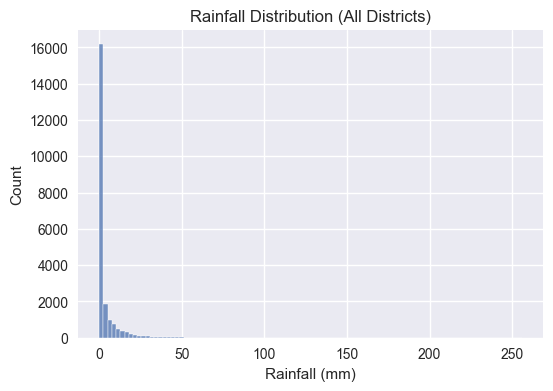

In [24]:
plt.figure(figsize=(6,4))
sns.histplot(df["rainfall_mm"], bins=100)
plt.title("Rainfall Distribution (All Districts)")
plt.xlabel("Rainfall (mm)")
plt.show()

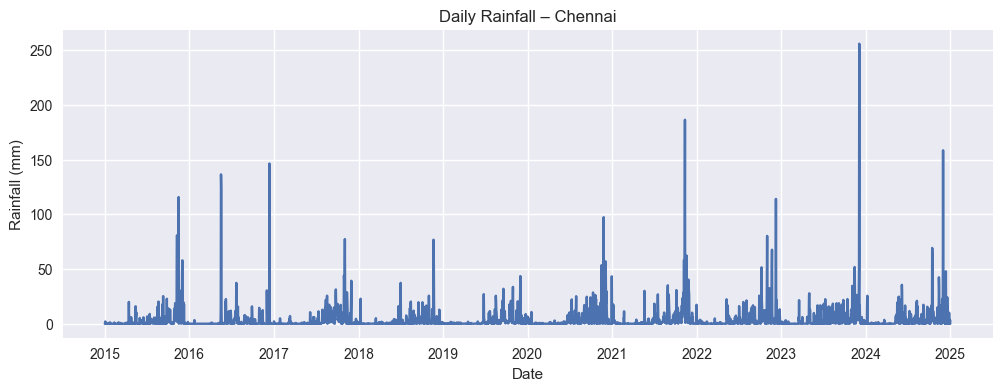

In [25]:
sample_district = "Chennai"

subset = df[df["district"] == sample_district]

plt.figure(figsize=(12,4))
plt.plot(subset["date"], subset["rainfall_mm"])
plt.title(f"Daily Rainfall – {sample_district}")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.show()

In [26]:
cols = [
    "temperature_2m_mean",
    "relative_humidity_2m_mean",
    "surface_pressure_mean",
    "wind_speed_10m_mean",
    "cloud_cover_mean"
]

df[cols].describe()

,temperature_2m_mean,relative_humidity_2m_mean,surface_pressure_mean,wind_speed_10m_mean,cloud_cover_mean
count,21918.000000,21918.000000,21918.000000,21918.000000,21918.000000
mean,28.012369,73.903869,1004.856492,11.421863,65.018113
std,2.494107,9.067285,4.900377,3.648213,29.035608
min,21.000000,37.000000,989.600000,3.300000,0.000000
25%,25.900000,69.000000,1001.400000,8.700000,41.000000
50%,28.100000,74.000000,1005.100000,10.900000,70.000000
75%,29.900000,80.000000,1008.500000,13.600000,93.000000
max,36.500000,97.000000,1016.900000,43.000000,100.000000


In [27]:
df.isna().sum()


date                         0
district                     0
rainfall_mm                  0
temperature_2m_mean          0
relative_humidity_2m_mean    0
surface_pressure_mean        0
wind_speed_10m_mean          0
cloud_cover_mean             0
dtype: int64

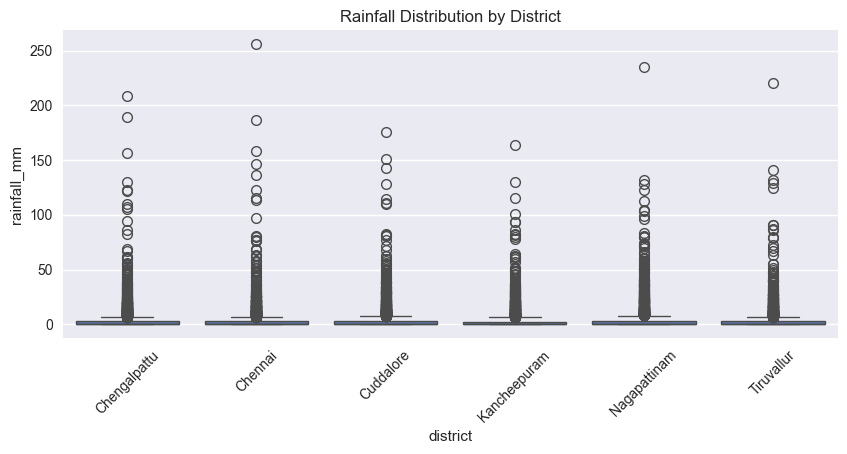

In [28]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x="district", y="rainfall_mm")
plt.title("Rainfall Distribution by District")
plt.xticks(rotation=45)
plt.show()